## Import

In [1]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
from xml.etree.ElementTree import fromstring, ElementTree
from Evtx.Evtx import Evtx
import csv

In [2]:
%load_ext autoreload
%autoreload 2
import preprocess
import main
import a

/home/ubuntu/My_lad/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
INTERIM_DIR = Path('../data/interim')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR = Path('../data/raw')
NO_MEANING_DIR = Path('../data/no_meaning')

## 検証

## データ作成

### refine データ作成
- securityログ
- T1105, VSCode1, WEB1, WEB2(正常データのみ)　を含む

In [ ]:
df = pd.read_csv(INTERIM_DIR/"Integrated/security2_structured.csv") 

In [5]:
cond = (df["Label"] == "anomaly") & (df["project"] == "WEB2")

idx = df.index[cond]
if len(idx) > 0:
    df = df.loc[:idx[0]-1]
    
df.loc[df["project"] == "WEB2", "project"] = "WEB2_C"
df.to_csv(INTERIM_DIR/"refine/security2_structured.csv")

In [ ]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_time",
    window_size = 1800, # 30min
    step_size = 900,
    mode = "time",
)

/home/siwamura/My_lad/src/preprocess.py:1006: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 3154 instances (sliding windows) in this dataset

there are 864 instances (sliding windows) in this dataset

there are 1100 instances (sliding windows) in this dataset

there are 805 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_time/ratio_0.8/train_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_normal_projects.csv
Project info saved to ../data/processed/refine_time/ratio_0.8/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_time/vocab/train_projects.csv
vocab size 5620
Sequence Length Statistics Report
Generated: 2025-12-21 21:57:25
Mode: time
Window Size: 1800
Step Size: 900

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    4,496
    Avg Len:  461.97
    Min Len:  97
    Max Len:  22258
    Std Dev:  479.56
  test_normal:
    Count:    1,124
    Avg Len:  481.16
    Min Len:  5
    Max Len:  21798
    Std Dev:  725.68
  test_abnormal:


In [ ]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured.csv",
    output_dir = PROCESSED_DIR/"refine_fixed",
    window_size = 430, # 時間ベースの分割における平均値を採用(サンプル数が5000前後になるように調整)
    step_size = 200,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1006: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine_fixed/ratio_0.8/train_projects.csv
Project info saved to ../data/processed/refine_fixed/ratio_0.8/test_normal_projects.csv
Project info saved to ../data/processed/refine_fixed/ratio_0.8/test_abnormal_projects.csv
Project info saved to ../data/processed/refine_fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-22 00:47:45
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
  

In [4]:
preprocess.prepare_refine_model_data(
    logdata_filepath = INTERIM_DIR/"refine/security2_structured_unmasked.csv",
    output_dir = PROCESSED_DIR/"refine2/fixed",
    event_id="EventTemplateUnmaskedHash",
    features = ["EventTemplateUnmaskedHash", "deltaT"],
    use_columns = ["timestamp", "Label", "EventID", "EventTemplateUnmaskedHash", "deltaT"],
    window_size = 430,
    step_size = 200,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1008: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  data["timestamp"] = data["datetime"].view("int64") // 10**9


there are 4248 instances (sliding windows) in this dataset

there are 887 instances (sliding windows) in this dataset

there are 969 instances (sliding windows) in this dataset

there are 720 instances (sliding windows) in this dataset

Project info saved to ../data/processed/refine2/fixed/train_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_normal_projects.csv
Project info saved to ../data/processed/refine2/fixed/test_abnormal_projects.csv
Project info saved to ../data/processed/refine2/fixed/vocab/train_projects.csv
vocab size 6573
Sequence Length Statistics Report
Generated: 2025-12-25 18:12:59
Mode: fixed
Window Size: 430
Step Size: 200

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    5,258
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_normal:
    Count:    1,315
    Avg Len:  430.00
    Min Len:  430
    Max Len:  430
    Std Dev:  0.00
  test_abnormal:
    Count:    251
    Avg Le

In [4]:
# train
main.main_cli([
    "train",
    "bert/refine2",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

setup
Building Vocab


100%|██████████| 6573/6573 [00:00<00:00, 12040.53it/s]


VOCAB SIZE: 180786
DEBUG suggest_dataloader: cfg.dataset.vocab.vocab_size = None (type: <class 'str'>)
Updating vocab_size from None to 180786
After update: cfg.dataset.vocab.vocab_size = 180786
before filtering short session
train size  4733
valid size  525


100%|██████████| 5258/5258 [00:02<00:00, 2262.94it/s]


Num of train seqs 4733
Num of valid seqs 525
DEBUG main.py: cfg.dataset.vocab.vocab_size = 180786 (type: <class 'int'>)


...

epoch 57 || TRAIN_Loss:6.3757 ||VAL_Loss:6.3925
Best epoch = 39


147it [00:24,  6.09it/s]
16it [00:00, 17.57it/s]


epoch 58 || TRAIN_Loss:6.3755 ||VAL_Loss:6.3902
Best epoch = 39


147it [00:24,  6.08it/s]
16it [00:00, 17.44it/s]


epoch 59 || TRAIN_Loss:6.3777 ||VAL_Loss:6.3831
Early stopping at epoch 59 (best = 39)


In [15]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "4",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert_no_time/refine2/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 6573/6573 [00:00<00:00, 11655.87it/s]


VOCAB SIZE: 180786
Updated vocab_size to 180786


100%|██████████| 251/251 [00:03<00:00, 76.31it/s]

Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['1283.0000', '248.0000', '29.0000', '3.0000', '16.1986', '98.8048', '27.8339', '98.8048', '97.7896']
threshold=0.100['1268.0000', '236.0000', '44.0000', '15.0000', '15.6915', '94.0239', '26.8946', '94.0239', '96.6463']
threshold=0.200['1261.0000', '233.0000', '51.0000', '18.0000', '15.5957', '92.8287', '26.7049', '92.8287', '96.1128']
threshold=0.300['1252.0000', '225.0000', '60.0000', '26.0000', '15.2336', '89.6414', '26.0417', '89.6414', '95.4268']
threshold=0.400['1105.0000', '111.0000', '207.0000', '140.0000', '9.1283', '44.2231', '15.1329', '44.2231', '84.2226']
threshold=0.500['571.0000', '9.0000', '741.0000', '242.0000', '1.5517', '3.5857', '2.1661', '3.5857', '43.5213']
threshold=0.600['70.0000', '7.0000', '1242.0000', '244.0000', '9.0909', '2.7888', '4.2683', '2.7888', '5.3354']
threshold=0.700['5.0000', '7.0000', '1307.0000', '244.0000', '58.3333',

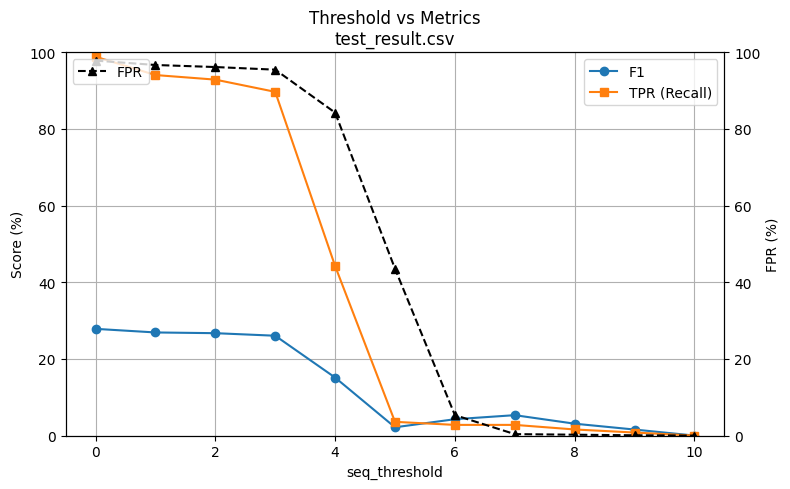

In [ ]:
a.plot_threshold_metrics(Path("../archive/0/refine2/fixed/seq_len_512/r_seed_31/test_result.csv"))

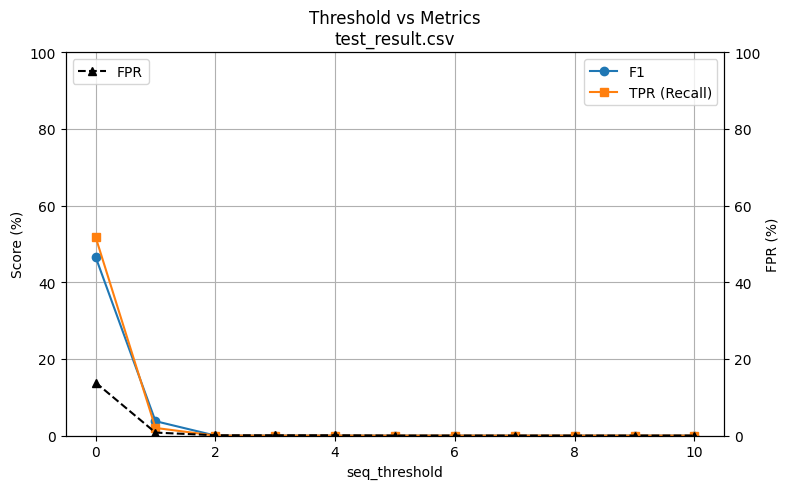

In [8]:
a.plot_threshold_metrics(Path("../output/logbert/bert/refine/fixed/seq_len_512/r_seed_31/test_result.csv"))

### BGL

In [ ]:
preprocess.prepare_bgl_model_data(
    logdata_filepath = INTERIM_DIR/"BGL/BGL_structured.csv",
    output_dir = PROCESSED_DIR/"BGL",
    window_size = 300, # 時間ベースの分割における平均値を採用
    step_size = 60,
    mode = "time",
)

In [17]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train_full"),
    output_file=Path(PROCESSED_DIR/"BGL/ratio_0.8/train")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/bgl",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [12]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 9993.12it/s] 


VOCAB SIZE: 237


Processing abnormal test data: 100%|██████████| 2584/2584 [00:01<00:00, 1433.51it/s]


Building Vocab


100%|██████████| 16268/16268 [00:01<00:00, 10361.58it/s]


VOCAB SIZE: 237


100%|██████████| 2584/2584 [00:14<00:00, 179.13it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['860.0000', '2578.0000', '2340.0000', '6.0000', '74.9855', '99.7678', '85.6194', '99.7678', '26.8750']
threshold=0.100['558.0000', '2333.0000', '2642.0000', '251.0000', '80.6987', '90.2864', '85.2237', '90.2864', '17.4375']
threshold=0.200['460.0000', '2185.0000', '2740.0000', '399.0000', '82.6087', '84.5588', '83.5724', '84.5588', '14.3750']
threshold=0.300['417.0000', '2038.0000', '2783.0000', '546.0000', '83.0143', '78.8700', '80.8891', '78.8700', '13.0312']
threshold=0.400['390.0000', '1894.0000', '2810.0000', '690.0000', '82.9247', '73.2972', '77.8143', '73.2972', '12.1875']
threshold=0.500['338.0000', '1792.0000', '2862.0000', '792.0000', '84.1315', '69.3498', '76.0289', '69.3498', '10.5625']
threshold=0.600['270.0000', '1688.0000', '2930.0000', '896.0000', '86.2104', '65.3251', '74.3285', '65.3251', '8.4375']
threshold=0.700['263.0000', '1593.0000', '

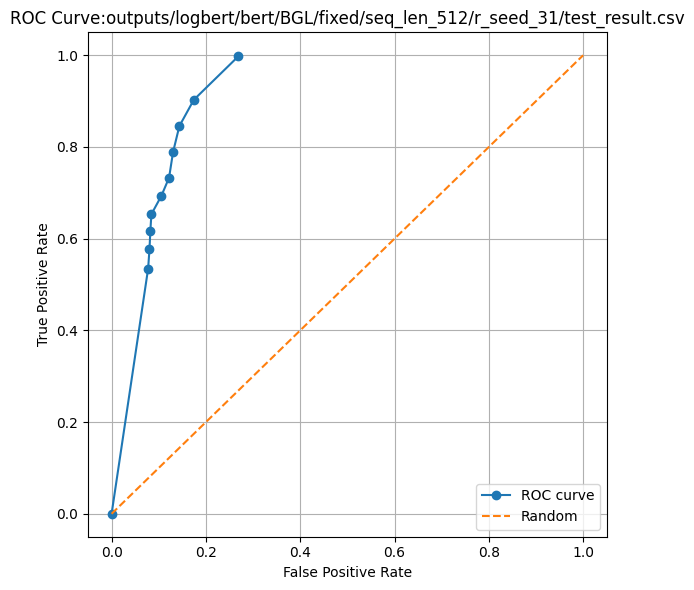

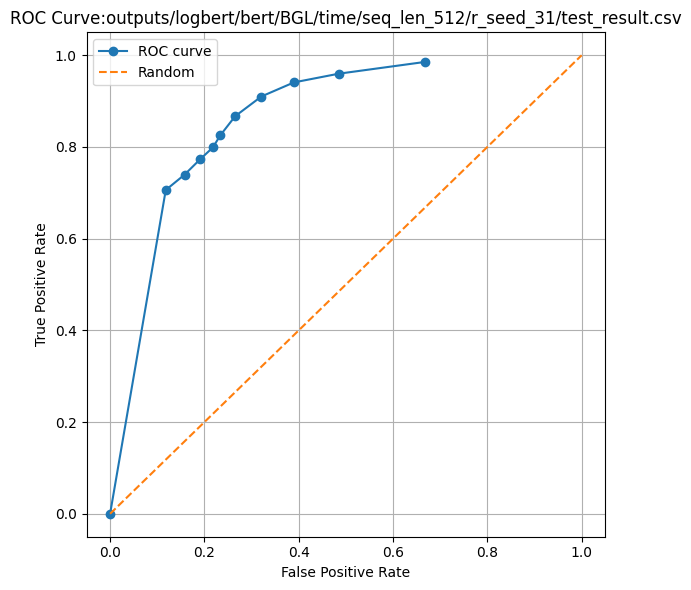

In [19]:
a.plot_roc(Path("outputs/logbert/bert/BGL/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/BGL/time/seq_len_512/r_seed_31/test_result.csv"))


### Tbird

In [28]:
preprocess.prepare_tbird_model_data(
    logdata_filepath = INTERIM_DIR/"Tbird/Thunderbird_structured.csv",
    output_dir = PROCESSED_DIR/"Tbird/fixed",
    window_size = 300, 
    step_size = 150,
    mode = "fixed",
)

/home/siwamura/My_lad/src/preprocess.py:1286: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['deltaT'].fillna(0, inplace=True)


there are 133332 instances (sliding windows) in this dataset

vocab size 79166
Sequence Length Statistics Report
Generated: 2025-12-21 19:40:07
Mode: fixed
Window Size: 300
Step Size: 150

[Ratio: 0.8]
--------------------------------------------------
  train:
    Count:    63,332
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_normal:
    Count:    15,834
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00
  test_abnormal:
    Count:    54,166
    Avg Len:  300.00
    Min Len:  300
    Max Len:  300
    Std Dev:  0.00


Statistics saved to: ../data/processed/Tbird/fixed/seq_stats.txt


In [29]:
# サンプル数を5000まで削る
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/train_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/train")
)

In [30]:
preprocess.extract_line(
    input_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal_full"),
    output_file=Path(PROCESSED_DIR/"Tbird/fixed/test_abnormal")
)

In [ ]:
# train
main.main_cli([
    "train",
    "bert/tbird",           # conf/bert_config_name.yaml
    #"default.device_id=0",        # ここに好きな key=value を並べる
    #"default.epochs=10",
])

In [33]:
# テスト
main.main_cli([
    "test",  # run_mode
    "outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/weights/ValTotalbest.pth", # 重みファイルまでの相対パス
    "64",   # eval_batchsize
    "cuda:0",     # gpu
])

outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31
cuda:0 cuda:0
Building Vocab


100%|██████████| 79166/79166 [00:04<00:00, 16982.03it/s]


VOCAB SIZE: 1159


100%|██████████| 44892/44892 [03:57<00:00, 188.98it/s]


Saving test normal results
Saving test abnormal results
[seq_th, FP, TP, TN, FN, Precision, Recall, F1, TPR, FPR]
threshold=0.000['12613.0000', '44824.0000', '3195.0000', '68.0000', '78.0403', '99.8485', '87.6076', '99.8485', '79.7887']
threshold=0.100['10273.0000', '44351.0000', '5535.0000', '541.0000', '81.1932', '98.7949', '89.1334', '98.7949', '64.9861']
threshold=0.200['9062.0000', '43545.0000', '6746.0000', '1347.0000', '82.7742', '96.9995', '89.3240', '96.9995', '57.3254']
threshold=0.300['8233.0000', '42231.0000', '7575.0000', '2661.0000', '83.6854', '94.0724', '88.5754', '94.0724', '52.0812']
threshold=0.400['7538.0000', '37227.0000', '8270.0000', '7665.0000', '83.1610', '82.9257', '83.0432', '82.9257', '47.6847']
threshold=0.500['6882.0000', '28790.0000', '8926.0000', '16102.0000', '80.7076', '64.1317', '71.4711', '64.1317', '43.5349']
threshold=0.600['6245.0000', '22850.0000', '9563.0000', '22042.0000', '78.5358', '50.8999', '61.7676', '50.8999', '39.5053']
threshold=0.700['

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


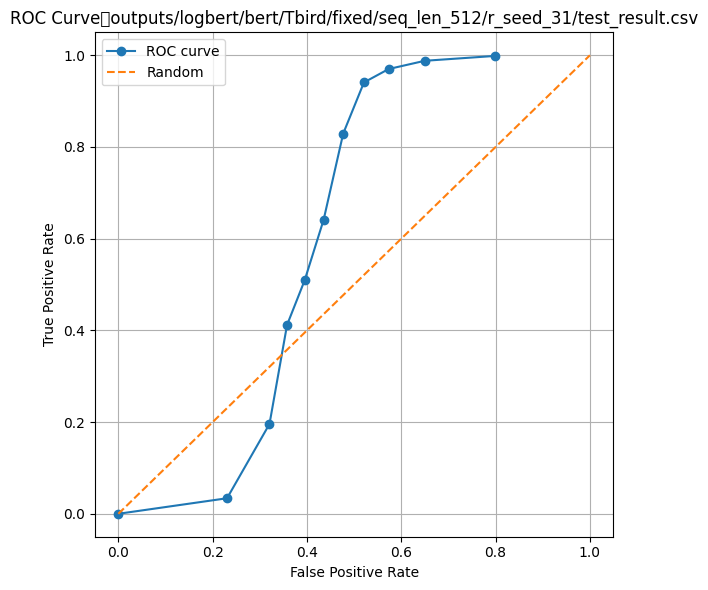

/home/siwamura/My_lad/src/a.py:13: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  tpr = df["TPR"] / 100.0
/home/siwamura/My_lad/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


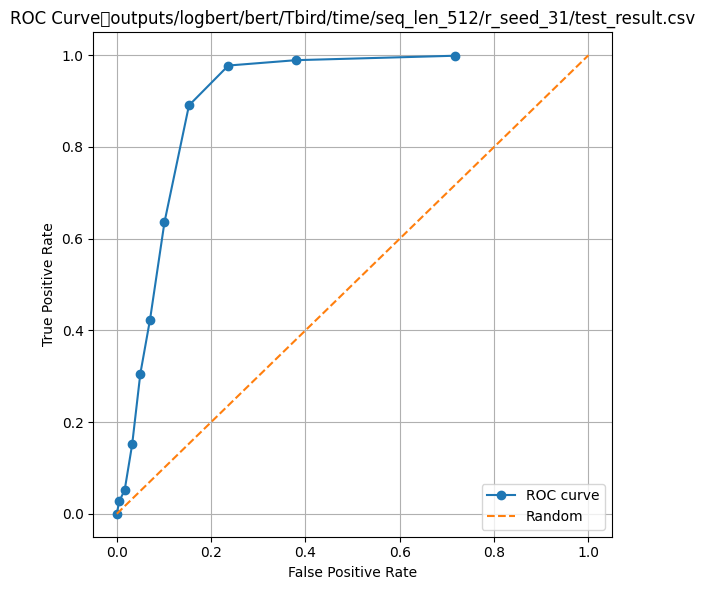

In [43]:
a.plot_roc(Path("outputs/logbert/bert/Tbird/fixed/seq_len_512/r_seed_31/test_result.csv"))
a.plot_roc(Path("outputs/logbert/bert/Tbird/time/seq_len_512/r_seed_31/test_result.csv"))
